# Imports & SetUp

In [1]:
import os
import copy
import json
import math
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
from pathlib import Path
from typing import Tuple
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import utils, transforms, datasets
from torch.utils.data import Dataset, DataLoader, random_split, Subset

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [5]:
from paths_setup import TRAIN_DIR, TEST_DIR, BACKUP_DIR

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")
if not TEST_DIR.exists():
    raise FileNotFoundError(f"TEST_DIR not found: {TEST_DIR}")
if not BACKUP_DIR.exists():
    raise FileNotFoundError(f"BACKUP_DIR not found: {BACKUP_DIR}")

In [6]:
VIEW_CLASS = ["02", "06", "08", "12", "13", "14", "15", "16", "18", "21", "22", "23", "27", "30"]

missing_train = [c for c in VIEW_CLASS if not (TRAIN_DIR / c).exists()]
missing_test  = [c for c in VIEW_CLASS if not (TEST_DIR  / c).exists()]

if missing_train:
    raise FileNotFoundError(f"Missing train class folders: {missing_train}")
if missing_test:
    raise FileNotFoundError(f"Missing test class folders: {missing_test}")

In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
NUM_WORKERS = 8

# Data Exploration

## General Information

In [9]:
def show_first_10_images(folder_dir: Path, view_name: str) -> None:
    
    view_dir = Path(folder_dir) / view_name
    png_files = sorted(view_dir.glob("*.png"))[:10]

    if not view_dir.exists():
        raise FileNotFoundError(f"Folder does not exist: {view_dir}")

    if len(png_files) == 0:
        raise FileNotFoundError(f"No PNG files found in: {view_dir}")

    n = len(png_files)
    rows, cols = 2, 5

    plt.figure(figsize=(cols * 3.2, rows * 3.2))

    for i in range(rows * cols):
        plt.subplot(rows, cols, i + 1)
        plt.axis("off")

        if i < n:
            img = Image.open(png_files[i])
            plt.imshow(img)
        else:
            plt.text(0.5, 0.5, "EMPTY", ha="center", va="center")

    plt.tight_layout()
    plt.show()

In [10]:
def count_pngs(folder: Path) -> int:
    
    if not folder.exists() or not folder.is_dir():
        return 0
    return sum(1 for p in folder.iterdir() if p.is_file() and p.suffix.lower() == ".png")

In [11]:
def print_view_image_counts(view_name: str) -> Tuple[int, int]:

    view_name = str(view_name).strip()
    
    train_view_dir = TRAIN_DIR / view_name
    test_view_dir  = TEST_DIR / view_name

    train_count = count_pngs(train_view_dir)
    test_count  = count_pngs(test_view_dir)

    return train_count, test_count

In [12]:
total_train = 0
total_test  = 0
counts_matrix = []

print(f"--- Data Summary ---")

for vc in VIEW_CLASS:
    temp_train, temp_test = print_view_image_counts(vc)

    counts_matrix.append([temp_train, temp_test])
    
    total_train += temp_train
    total_test  += temp_test
    
    print(f"View {vc}: {temp_train + temp_test} images ({temp_train} train images; {temp_test} test images)")
    
print(f"Total: {total_train + total_test} images ({total_train} train images; {total_test} test images)")

--- Data Summary ---
View 02: 19566 images (15317 train images; 4249 test images)
View 06: 10401 images (10000 train images; 401 test images)
View 08: 13020 images (10272 train images; 2748 test images)
View 12: 22663 images (18030 train images; 4633 test images)
View 13: 17814 images (14385 train images; 3429 test images)
View 14: 11139 images (10000 train images; 1139 test images)
View 15: 31473 images (25052 train images; 6421 test images)
View 16: 12061 images (10000 train images; 2061 test images)
View 18: 11058 images (10000 train images; 1058 test images)
View 21: 14059 images (11160 train images; 2899 test images)
View 22: 10895 images (10000 train images; 895 test images)
View 23: 13723 images (10930 train images; 2793 test images)
View 27: 11670 images (10000 train images; 1670 test images)
View 30: 10803 images (10000 train images; 803 test images)
Total: 210345 images (175146 train images; 35199 test images)


In [13]:
def plot_train_test_counts_stacked(view_classes: list[str], counts_matrix: list[list[int]]) -> None:
    
    if len(view_classes) != len(counts_matrix):
        raise ValueError(f"Length mismatch: view_classes - {len(view_classes)} entries, counts_matrix - {len(counts_matrix)} rows")

    train_counts = [row[0] for row in counts_matrix]
    test_counts  = [row[1] for row in counts_matrix]

    x = list(range(len(view_classes)))

    plt.figure(figsize=(max(10, len(view_classes) * 0.9), 5))

    plt.bar(x, train_counts, width=0.80, color="C0", label="Train")
    plt.bar(x, test_counts,  width=0.80, color="C1", label="Test", bottom=train_counts)

    plt.xticks(x, view_classes)
    plt.xlabel("View")
    plt.ylabel("Number of Images (Train + Test)")
    plt.title("Images per View")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
def plot_train_test_counts_overlaid(view_classes: list[str], counts_matrix: list[list[int]]) -> None:
    
    if len(view_classes) != len(counts_matrix):
        raise ValueError(f"Length mismatch: view_classes - {len(view_classes)} entries, counts_matrix - {len(counts_matrix)} rows")

    train_counts = [row[0] for row in counts_matrix]
    test_counts  = [row[1] for row in counts_matrix]

    x = list(range(len(view_classes)))
    
    plt.figure(figsize=(max(10, len(view_classes) * 0.9), 5))

    plt.bar(x, train_counts, width=0.80, color="C0", alpha=0.5, label="Train", zorder=1)
    plt.bar(x, test_counts,  width=0.80, color="C1", alpha=0.5, label="Test",  zorder=2)

    plt.xticks(x, view_classes)
    plt.xlabel("View")
    plt.ylabel("Number of Images (Train and Test - Overlaid)")
    plt.title("Images per View")
    plt.legend()
    plt.tight_layout()
    plt.show()

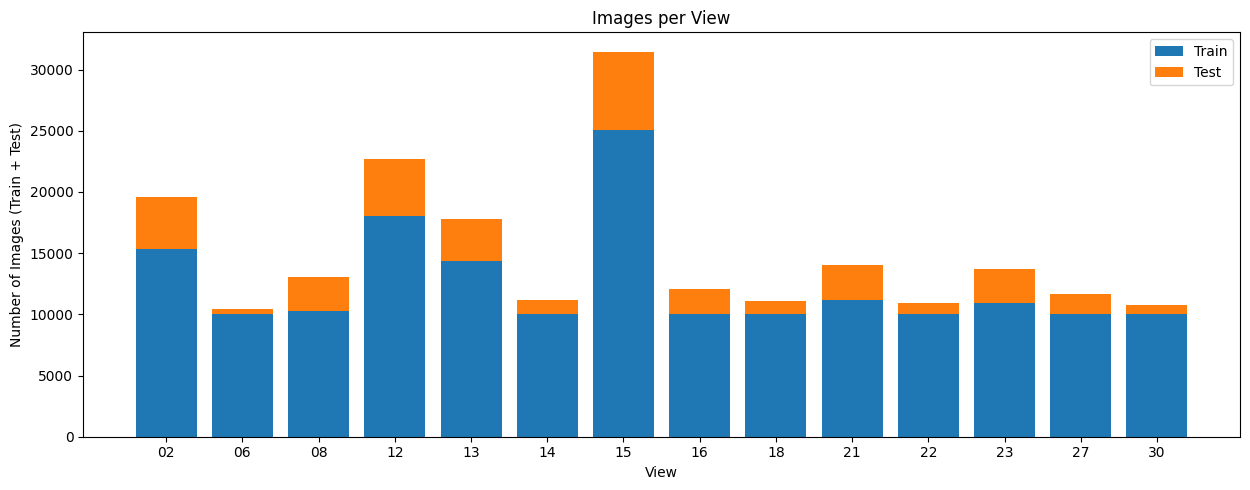

In [15]:
plot_train_test_counts_stacked(VIEW_CLASS, counts_matrix)

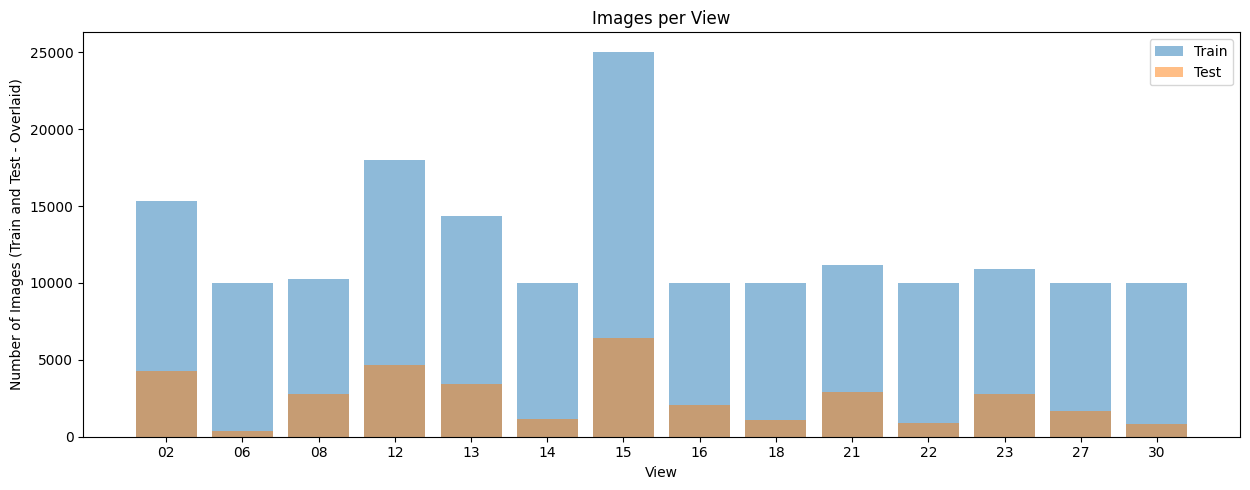

In [16]:
plot_train_test_counts_overlaid(VIEW_CLASS, counts_matrix)

## Label Mapping

In [17]:
class_to_idx = {name: i for i, name in enumerate(VIEW_CLASS)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

print("Label mapping:")
for k in sorted(class_to_idx.keys()):
    print(f"   {k} -> {class_to_idx[k]}")

Label mapping:
   02 -> 0
   06 -> 1
   08 -> 2
   12 -> 3
   13 -> 4
   14 -> 5
   15 -> 6
   16 -> 7
   18 -> 8
   21 -> 9
   22 -> 10
   23 -> 11
   27 -> 12
   30 -> 13


## Check Image Size Consistency

In [18]:
EXCLUDED_FILES = []

def verify_image_dimensions(folder_dir: Path, target_size: Tuple[int, int]) -> None:
    print(f"Checking image dimensions in {folder_dir}:")
    total_mismatch = 0 
    
    for class_name in VIEW_CLASS:
        mismatch_count = 0
        
        print(f"\n   View {class_name}:")
        class_path = folder_dir / class_name
        if not class_path.exists():
            continue
            
        for img_path in class_path.glob("*.png"):
            with Image.open(img_path) as img:
                if img.size != target_size:
                    mismatch_count += 1
                    total_mismatch += 1
                    EXCLUDED_FILES.append(img_path.name)
                    print(f"      Mismatch found: {img_path.name} is {img.size}")

        if mismatch_count == 0:
            print("      No mismatches found")

    if total_mismatch == 0:
        print(f"\nSuccess: All images are confirmed to be {target_size}")
    else:
        print(f"\nWARNING: Found {total_mismatch} images with inconsistent sizes")

In [19]:
verify_image_dimensions(TRAIN_DIR, IMG_SIZE)

Checking image dimensions in /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/Dataset/View Classification/train:

   View 02:
      Mismatch found: __Amy__DicomIMG_ID_69214103__20200810140438__1.png is (432, 288)
      Mismatch found: __DCM__DicomIMG_ID_60302307__nk095938.000000__1.png is (432, 288)

   View 06:
      No mismatches found

   View 08:
      No mismatches found

   View 12:
      No mismatches found

   View 13:
      No mismatches found

   View 14:
      No mismatches found

   View 15:
      No mismatches found

   View 16:
      No mismatches found

   View 18:
      No mismatches found

   View 21:
      No mismatches found

   View 22:
      No mismatches found

   View 23:
      No mismatches found

   View 27:
      No mismatches found

   View 30:
      No mismatches found



In [20]:
verify_image_dimensions(TEST_DIR, IMG_SIZE)

Checking image dimensions in /mnt/c/Users/ROG/MyProjects/Quantum/CardioQML/Dataset/View Classification/test:

   View 02:
      No mismatches found

   View 06:
      No mismatches found

   View 08:
      No mismatches found

   View 12:
      No mismatches found

   View 13:
      No mismatches found

   View 14:
      No mismatches found

   View 15:
      No mismatches found

   View 16:
      No mismatches found

   View 18:
      No mismatches found

   View 21:
      No mismatches found

   View 22:
      No mismatches found

   View 23:
      No mismatches found

   View 27:
      No mismatches found

   View 30:
      No mismatches found

Success: All images are confirmed to be (224, 224)


In [21]:
print(f"Files to exclude: {EXCLUDED_FILES}")

Files to exclude: ['__Amy__DicomIMG_ID_69214103__20200810140438__1.png', '__DCM__DicomIMG_ID_60302307__nk095938.000000__1.png']


## View 02

In [ ]:
show_first_10_images(TRAIN_DIR, "02")
show_first_10_images(TEST_DIR,  "02")

## View 06

In [ ]:
show_first_10_images(TRAIN_DIR, "06")
show_first_10_images(TEST_DIR,  "06")

## View 08

In [ ]:
show_first_10_images(TRAIN_DIR, "08")
show_first_10_images(TEST_DIR,  "08")

## View 12

In [ ]:
show_first_10_images(TRAIN_DIR, "12")
show_first_10_images(TEST_DIR,  "12")

## View 13

In [ ]:
show_first_10_images(TRAIN_DIR, "13")
show_first_10_images(TEST_DIR,  "13")

## View 14

In [ ]:
show_first_10_images(TRAIN_DIR, "14")
show_first_10_images(TEST_DIR,  "14")

## View 15

In [ ]:
show_first_10_images(TRAIN_DIR, "15")
show_first_10_images(TEST_DIR,  "15")

## View 16

In [ ]:
show_first_10_images(TRAIN_DIR, "16")
show_first_10_images(TEST_DIR,  "16")

## View 18

In [ ]:
show_first_10_images(TRAIN_DIR, "18")
show_first_10_images(TEST_DIR,  "18")

## View 21

In [ ]:
show_first_10_images(TRAIN_DIR, "21")
show_first_10_images(TEST_DIR,  "21")

## View 22

In [ ]:
show_first_10_images(TRAIN_DIR, "22")
show_first_10_images(TEST_DIR,  "22")

## View 23

In [ ]:
show_first_10_images(TRAIN_DIR, "23")
show_first_10_images(TEST_DIR,  "23")

## View 27

In [ ]:
show_first_10_images(TRAIN_DIR, "27")
show_first_10_images(TEST_DIR,  "27")

## View 30

In [ ]:
show_first_10_images(TRAIN_DIR, "30")
show_first_10_images(TEST_DIR,  "30")

# Data Preprocessing

## Data Transforms

In [22]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
    
    'val': transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ]),
}

## Load & Split Data

In [23]:
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        
        if self.transform:
            x = self.transform(x)
            
        return x, y
        
    def __len__(self):
        return len(self.subset)

In [24]:
def is_valid_image(path):
    if os.path.basename(path) in EXCLUDED_FILES:
        return False 
    return path.lower().endswith('.png')

In [25]:
base_dataset = datasets.ImageFolder(root=TRAIN_DIR, is_valid_file=is_valid_image) 

train_size = int((1 - VAL_SPLIT) * len(base_dataset))
val_size = len(base_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(base_dataset, [train_size, val_size], generator=generator)

train_data = TransformedSubset(train_subset, transform=data_transforms['train'])
val_data   = TransformedSubset(val_subset,   transform=data_transforms['val'])

test_data = datasets.ImageFolder(root=TEST_DIR, is_valid_file=is_valid_image, transform=data_transforms['val'])

In [26]:
def get_counts(subset):
    targets = [subset.dataset.targets[i] for i in subset.indices]
    return np.bincount(targets, minlength=len(base_dataset.classes))

train_counts = get_counts(train_subset)
val_counts = get_counts(val_subset)
test_counts = np.bincount(test_data.targets, minlength=len(base_dataset.classes))

print(f"Dataset split (Total = {len(base_dataset) + len(test_data)}):")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Train = {train_counts[i]}, Val = {val_counts[i]}, Test = {test_counts[i]}")

print("Training set size: ", len(train_data))
print("Validation set size: ", len(val_data))
print("Test set size: ", len(test_data))

Dataset split (Total = 210343):
   View 02: Train = 12276, Val = 3039, Test = 4249
   View 06: Train = 7911, Val = 2089, Test = 401
   View 08: Train = 8211, Val = 2061, Test = 2748
   View 12: Train = 14457, Val = 3573, Test = 4633
   View 13: Train = 11455, Val = 2930, Test = 3429
   View 14: Train = 8009, Val = 1991, Test = 1139
   View 15: Train = 20015, Val = 5037, Test = 6421
   View 16: Train = 7995, Val = 2005, Test = 2061
   View 18: Train = 8030, Val = 1970, Test = 1058
   View 21: Train = 8917, Val = 2243, Test = 2899
   View 22: Train = 8037, Val = 1963, Test = 895
   View 23: Train = 8771, Val = 2159, Test = 2793
   View 27: Train = 7971, Val = 2029, Test = 1670
   View 30: Train = 8060, Val = 1940, Test = 803
Training set size:  140115
Validation set size:  35029
Test set size:  35199


## Class Weights

In [27]:
base_targets = train_data.subset.dataset.targets
train_indices = train_data.subset.indices
train_targets = [base_targets[i] for i in train_indices]

class_counts = np.bincount(train_targets)
total_samples = len(train_targets)
num_classes = len(class_counts)

class_weights = total_samples / (num_classes * class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

In [28]:
print("Class weights:")
for i, class_name in enumerate(base_dataset.classes):
    print(f"   View {class_name}: Count = {class_counts[i]}, Weight = {class_weights[i]:.4f}")

Class weights:
   View 02: Count = 12276, Weight = 0.8153
   View 06: Count = 7911, Weight = 1.2651
   View 08: Count = 8211, Weight = 1.2189
   View 12: Count = 14457, Weight = 0.6923
   View 13: Count = 11455, Weight = 0.8737
   View 14: Count = 8009, Weight = 1.2496
   View 15: Count = 20015, Weight = 0.5000
   View 16: Count = 7995, Weight = 1.2518
   View 18: Count = 8030, Weight = 1.2464
   View 21: Count = 8917, Weight = 1.1224
   View 22: Count = 8037, Weight = 1.2453
   View 23: Count = 8771, Weight = 1.1411
   View 27: Count = 7971, Weight = 1.2556
   View 30: Count = 8060, Weight = 1.2417


## Data Loaders

In [29]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [ ]:
def show_batch(loader):
    images, labels = next(iter(loader))
    
    print(f"Batch shape: {images.shape}")
    
    plt.figure(figsize=(16, 8))
    
    images = images * 0.5 + 0.5 
    
    grid_img = utils.make_grid(images, nrow=8, padding=2)
    
    plt.imshow(grid_img.permute(1, 2, 0), cmap="gray")
    plt.axis('off')
    plt.title("Batch of Preprocessed Training Images (Grayscale)")
    plt.show()

show_batch(train_loader)

# Testing Models

## Utility Functions

In [31]:
num_classes = len(base_dataset.classes)

In [32]:
class_mapping_path = BACKUP_DIR / "class_mapping.json"
with open(class_mapping_path, "w") as f:
    json.dump(base_dataset.classes, f)
print(f"Saved class mapping")

Saved class mapping


In [33]:
def train_model(model_name, model, criterion, optimizer, train_loader, val_loader, num_epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    best_model_wts = copy.deepcopy(model.state_dict())
    
    best_val_acc = 0.0
    best_train_acc = 0.0
    
    print(f"Starting training {model_name} model for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())

                if epoch_acc > best_train_acc:
                    best_train_acc = epoch_acc
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                
                if epoch_acc > best_val_acc:
                    best_val_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print()

    print(f'\nBest Val Acc:   {best_val_acc:.4f}')
    print(f'Best Train Acc: {best_train_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

In [34]:
def plot_learning_curves(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)
    
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    label_acc = f'Best Acc ({val_acc[best_acc_epoch]:.4f}): Epoch {best_acc_epoch + 1}'
    plt.scatter(best_acc_epoch + 1, val_acc[best_acc_epoch], s=100, c='green', label=label_acc)
    
    plt.legend(loc='lower right')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    label_loss = f'Best Loss ({val_loss[best_loss_epoch]:.4f}): Epoch {best_loss_epoch + 1}'
    plt.scatter(best_loss_epoch + 1, val_loss[best_loss_epoch], s=100, c='red', label=label_loss)
    
    plt.legend(loc='upper right')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [35]:
def evaluate_model(model, dataloader, classes):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    print("--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=classes))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.show()

In [38]:
def save_model(trained_model, model_path, model_name):
    torch.save(trained_model.state_dict(), BACKUP_DIR / model_path)
    print(f"Saved model weights for {model_name}: {model_path}")

## CNN

### Define Model

In [39]:
model_name_viewcnn = "ViewCNN"
model_path_viewcnn = f"{model_name_viewcnn}.pth"

In [40]:
class ViewCNN(nn.Module):
    def __init__(self, num_classes):
        super(ViewCNN, self).__init__()
        
        # Block 1: Input (1, 224, 224) -> Output (32, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2: (32, 112, 112) -> (64, 56, 56)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Block 3: (64, 56, 56) -> (128, 28, 28)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Block 4: (128, 28, 28) -> (256, 14, 14)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc1 = nn.Linear(256, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

### Train & Save Model

In [41]:
model_viewcnn = ViewCNN(num_classes=num_classes).to(DEVICE)

criterion_viewcnn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_viewcnn = optim.Adam(model_viewcnn.parameters(), lr=1e-3)

num_epochs_viewcnn = 10

In [42]:
trained_model_viewcnn, history_viewcnn = train_model(model_name=model_name_viewcnn,
                                                     model=model_viewcnn,
                                                     criterion=criterion_viewcnn,
                                                     optimizer=optimizer_viewcnn,
                                                     train_loader=train_loader,
                                                     val_loader=val_loader,
                                                     num_epochs=num_epochs_viewcnn)

Starting training ViewCNN model for 10 epochs...

Epoch 1/10:
Train Loss: 1.1029 Acc: 0.5898
Val Loss: 9.0851 Acc: 0.1667


Epoch 2/10:
Train Loss: 0.4797 Acc: 0.8216
Val Loss: 3.8729 Acc: 0.3197


Epoch 3/10:
Train Loss: 0.2940 Acc: 0.8934
Val Loss: 2.2364 Acc: 0.6026


Epoch 4/10:
Train Loss: 0.2023 Acc: 0.9269
Val Loss: 0.9894 Acc: 0.7149


Epoch 5/10:
Train Loss: 0.1500 Acc: 0.9453
Val Loss: 0.9625 Acc: 0.7419


Epoch 6/10:
Train Loss: 0.1230 Acc: 0.9552
Val Loss: 0.1909 Acc: 0.9321


Epoch 7/10:
Train Loss: 0.1036 Acc: 0.9620
Val Loss: 0.3018 Acc: 0.9278


Epoch 8/10:
Train Loss: 0.0907 Acc: 0.9660
Val Loss: 0.0974 Acc: 0.9634


Epoch 9/10:
Train Loss: 0.0780 Acc: 0.9706
Val Loss: 0.4295 Acc: 0.8335


Epoch 10/10:
Train Loss: 0.0694 Acc: 0.9737
Val Loss: 0.3328 Acc: 0.9257


Best Val Acc:   0.9634
Best Train Acc: 0.9737


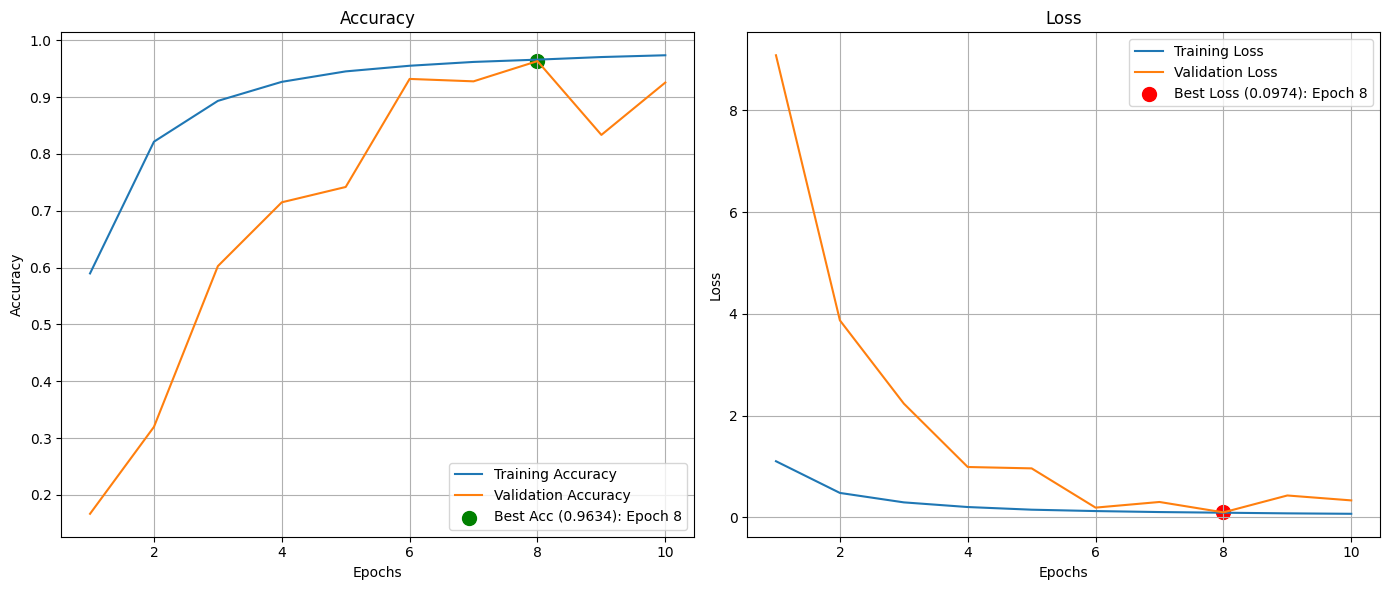

In [43]:
plot_learning_curves(history_viewcnn)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.83      0.82      0.82      4249
          06       0.00      0.00      0.00       401
          08       0.57      0.68      0.62      2748
          12       0.49      0.52      0.50      4633
          13       0.39      0.54      0.45      3429
          14       0.17      0.16      0.16      1139
          15       0.90      0.71      0.79      6421
          16       0.77      0.59      0.67      2061
          18       0.21      0.12      0.15      1058
          21       0.67      0.78      0.72      2899
          22       0.43      0.41      0.42       895
          23       0.66      0.81      0.73      2793
          27       0.98      0.84      0.91      1670
          30       0.85      0.64      0.73       803

    accuracy                           0.64     35199
   macro avg       0.56      0.54      0.55     35199
weighted avg       0.65      0.64      0.64     35

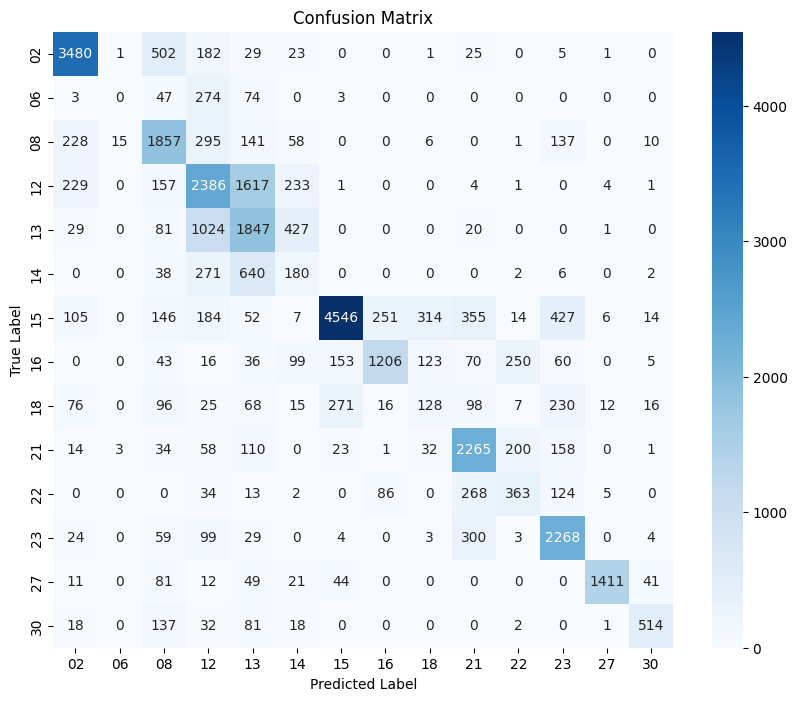

In [44]:
evaluate_model(trained_model_viewcnn, test_loader, base_dataset.classes)

In [45]:
save_model(trained_model_viewcnn, model_path_viewcnn, model_name_viewcnn)

Saved model weights for ViewCNN: ViewCNN.pth


### Load & Check Model

In [46]:
loaded_model_viewcnn = ViewCNN(num_classes=num_classes).to(DEVICE)

In [47]:
if not os.path.exists(BACKUP_DIR / model_path_viewcnn):
    raise FileNotFoundError(f"Model file not found: {model_path_viewcnn}")

In [ ]:
loaded_model_viewcnn.load_state_dict(torch.load(BACKUP_DIR / model_path_viewcnn))
loaded_model_viewcnn.eval()
evaluate_model(loaded_model_viewcnn, test_loader, base_dataset.classes)

## ResNet

### Define Model

In [48]:
model_name_viewresnet = "ViewResNet"
model_path_viewresnet = f"{model_name_viewresnet}.pth"

In [49]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        
        # First convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

class ViewResNet(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(ViewResNet, self).__init__()
        
        # Initial Convolution
        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet Layers
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        # Classification Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Initial processing
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual Layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Output Head
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

### Train & Save Model

In [50]:
model_viewresnet = ViewResNet(num_classes=num_classes).to(DEVICE)

criterion_viewresnet = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_viewresnet = optim.Adam(model_viewresnet.parameters(), lr=1e-3)

num_epochs_viewresnet = 10

In [51]:
trained_model_viewresnet, history_viewresnet = train_model(model_name=model_name_viewresnet,
                                                           model=model_viewresnet,
                                                           criterion=criterion_viewresnet,
                                                           optimizer=optimizer_viewresnet,
                                                           train_loader=train_loader,
                                                           val_loader=val_loader,
                                                           num_epochs=num_epochs_viewresnet)

Starting training ViewResNet model for 10 epochs...

Epoch 1/10:
Train Loss: 0.2652 Acc: 0.9023
Val Loss: 0.0860 Acc: 0.9672


Epoch 2/10:
Train Loss: 0.0523 Acc: 0.9795
Val Loss: 0.0719 Acc: 0.9640


Epoch 3/10:
Train Loss: 0.0333 Acc: 0.9841
Val Loss: 0.0553 Acc: 0.9779


Epoch 4/10:
Train Loss: 0.0272 Acc: 0.9859
Val Loss: 0.0303 Acc: 0.9829


Epoch 5/10:
Train Loss: 0.0227 Acc: 0.9871
Val Loss: 0.0166 Acc: 0.9886


Epoch 6/10:
Train Loss: 0.0209 Acc: 0.9878
Val Loss: 0.0142 Acc: 0.9897


Epoch 7/10:
Train Loss: 0.0187 Acc: 0.9890
Val Loss: 0.0136 Acc: 0.9896


Epoch 8/10:
Train Loss: 0.0189 Acc: 0.9889
Val Loss: 0.0140 Acc: 0.9906


Epoch 9/10:
Train Loss: 0.0168 Acc: 0.9893
Val Loss: 0.0299 Acc: 0.9856


Epoch 10/10:
Train Loss: 0.0160 Acc: 0.9894
Val Loss: 0.0175 Acc: 0.9900


Best Val Acc:   0.9906
Best Train Acc: 0.9894


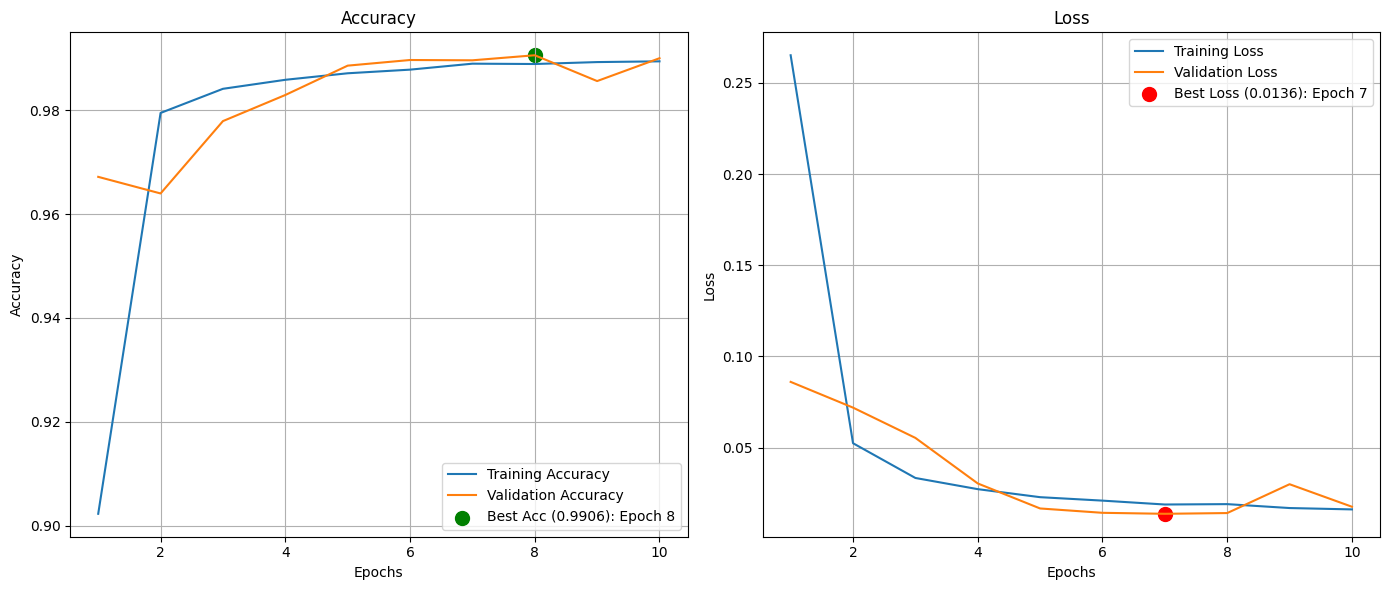

In [52]:
plot_learning_curves(history_viewresnet)

--- Classification Report ---
              precision    recall  f1-score   support

          02       0.93      0.93      0.93      4249
          06       0.87      0.62      0.73       401
          08       0.82      0.86      0.84      2748
          12       0.62      0.60      0.61      4633
          13       0.45      0.59      0.51      3429
          14       0.40      0.14      0.21      1139
          15       0.86      0.87      0.87      6421
          16       0.63      0.56      0.60      2061
          18       0.51      0.77      0.61      1058
          21       0.74      0.83      0.78      2899
          22       0.63      0.28      0.39       895
          23       0.93      0.86      0.90      2793
          27       0.97      0.83      0.89      1670
          30       0.89      0.92      0.90       803

    accuracy                           0.75     35199
   macro avg       0.73      0.69      0.70     35199
weighted avg       0.75      0.75      0.74     35

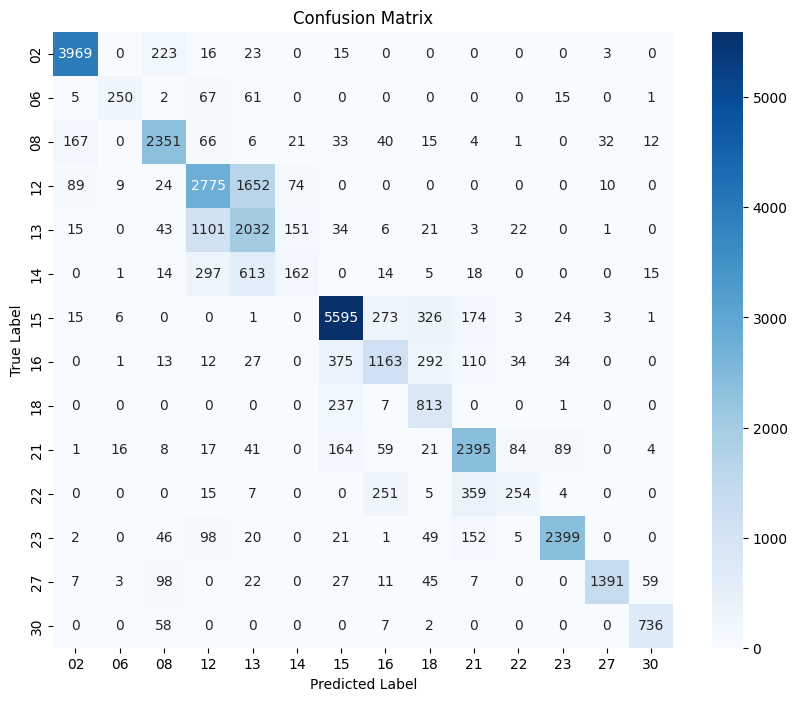

In [53]:
evaluate_model(trained_model_viewresnet, test_loader, base_dataset.classes)

In [54]:
save_model(trained_model_viewresnet, model_path_viewresnet, model_name_viewresnet)

Saved model weights for ViewResNet: ViewResNet.pth


### Load & Check Model

In [55]:
loaded_model_viewresnet = ViewResNet(num_classes=num_classes).to(DEVICE)

In [56]:
if not os.path.exists(BACKUP_DIR / model_path_viewresnet):
    raise FileNotFoundError(f"Model file not found: {model_path_viewresnet}")

In [ ]:
loaded_model_viewresnet.load_state_dict(torch.load(BACKUP_DIR / model_path_viewresnet))
loaded_model_viewresnet.eval()
evaluate_model(loaded_model_viewresnet, test_loader, base_dataset.classes)